# Customer 360 - Customer Segmentation 

### This notebook handles:

- K-Means
- Agglomerative Clustering
- DBSCAN

### Behavioral/value variables:

- TenureMonths
- MonthlyUsageGB
- MonthlyChargeEGP
- NumServices
- SupportCalls6M
- LatePayments12M
- SatisfactionScore
- SupportSatisfactionInteraction
- HighValueCustomer 
- LatePaymentRate 
- SupportCallsPerTenure 
- UsagePerService 
- ChargePerService

Missing values are imputed and the variables are standardized before clustering.

**The goal** is Discover customer groups based on behavior/value.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")


## Load Dataset

In [2]:
df = pd.read_csv('../data/processed/customer_360_features.csv')

In [3]:
segmentation_features = [
    "TenureMonths",
    "MonthlyUsageGB",
    "MonthlyChargeEGP",
    "NumServices",
    "SupportCalls6M",
    "LatePayments12M",
    "SatisfactionScore",
    "SupportSatisfactionInteraction",
    "HighValueCustomer",
    "LatePaymentRate",
    "SupportCallsPerTenure", 
    "UsagePerService", 
    "ChargePerService"
]

segmentation_data = df[segmentation_features].copy()

segmentation_data = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(segmentation_data),
    columns=segmentation_features
)

segmentation_scaled = StandardScaler().fit_transform(segmentation_data)

segmentation_scaled_df = pd.DataFrame(segmentation_scaled , columns= segmentation_features)

print("Segmentation matrix:", segmentation_scaled.shape)


Segmentation matrix: (3000, 13)


## K-Means


### inertia and silhouette score

In [4]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(segmentation_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(segmentation_scaled, labels))

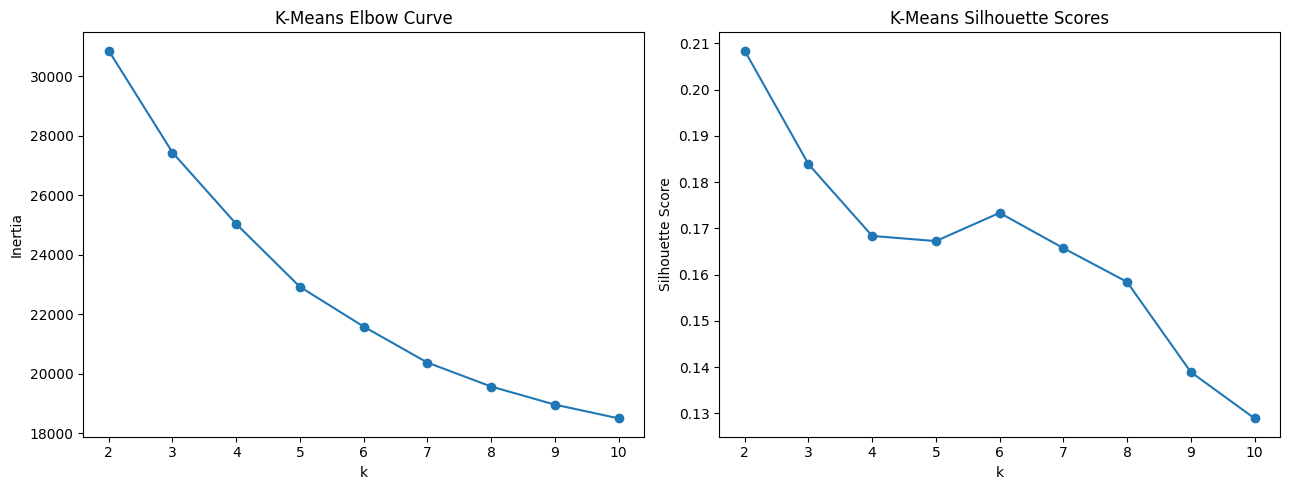

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("K-Means Elbow Curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouettes, marker="o")
axes[1].set_title("K-Means Silhouette Scores")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()

plt.show()

In [6]:
silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

silhouette_df

,k,Inertia,Silhouette
0,2,30862.651119,0.208437
1,3,27439.724109,0.183917
2,4,25036.594253,0.168392
3,5,22921.786800,0.167275
4,6,21585.981571,0.173382
5,7,20375.327252,0.165755
6,8,19570.292073,0.158445
7,9,18961.722491,0.138965
8,10,18500.051499,0.128952


### Select k using the strongest silhouette score

In [7]:
best_k = int(silhouette_df.loc[silhouette_df["Silhouette"].idxmax(), "k"])

print("Selected k based on highest silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(segmentation_scaled)

df["KMeansCluster"] = kmeans_labels


Selected k based on highest silhouette score: 2


### Cluster profiles

In [8]:
cluster_profile = df.groupby("KMeansCluster")[segmentation_features].mean().round(2)
cluster_sizes = df["KMeansCluster"].value_counts().sort_index()

cluster_sizes.rename("Customers").to_frame()
cluster_profile


,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,SupportSatisfactionInteraction,HighValueCustomer,LatePaymentRate,SupportCallsPerTenure,UsagePerService,ChargePerService
KMeansCluster,,,,,,,,,,,,,
0,25.17,239.62,581.67,4.89,2.25,1.11,3.51,3.34,0.96,9.21,0.16,52.39,123.69
1,25.91,220.54,392.77,2.14,2.16,1.12,3.48,3.26,0.04,9.31,0.16,136.11,226.50


### PCA visualization of K-Means segments

In [9]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(segmentation_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(2))
print("Total explained variance:", pca.explained_variance_ratio_.sum().round(2))

Explained variance ratio: [0.28 0.16]
Total explained variance: 0.44


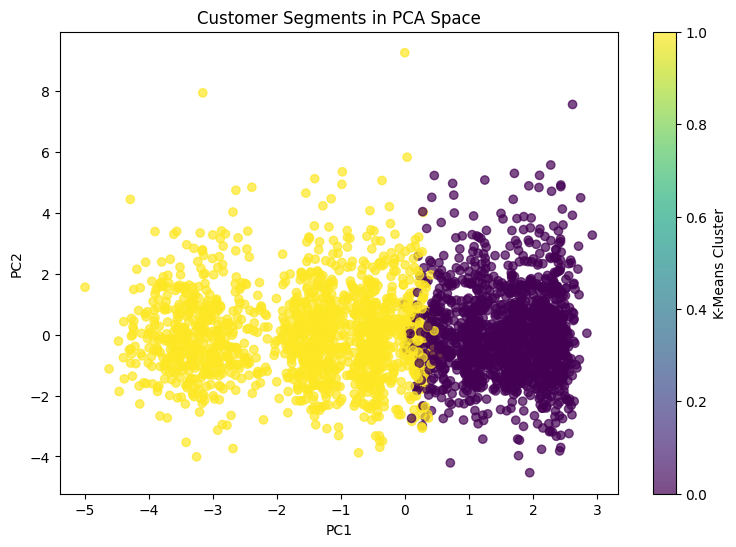

In [10]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments in PCA Space")

plt.colorbar(scatter, label="K-Means Cluster")

plt.show()

## Agglomerative Clustering

In [11]:
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(segmentation_scaled)

agg_silhouette = silhouette_score(segmentation_scaled, agg_labels)

print("Agglomerative silhouette score:", round(agg_silhouette, 4))

Agglomerative silhouette score: 0.181


## DBSCAN

DBSCAN does not require the number of clusters in advance.

The special label **-1** means that DBSCAN considers the observation an **outlier/noise point** under the selected density parameters.

### Selecting `eps`

In [12]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)

neighbors.fit(segmentation_scaled)

distances, indices = neighbors.kneighbors(segmentation_scaled)

k_distances = distances[:, -1]
k_distances = np.sort(k_distances)

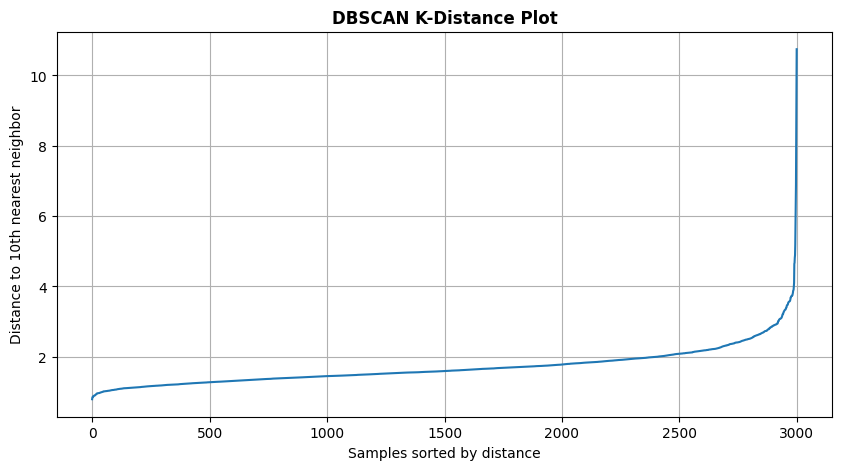

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Samples sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("DBSCAN K-Distance Plot" , fontweight = 'bold')

plt.grid(True)

plt.show()

From the k-distance plot, the curve begins to rise more sharply in the upper-distance region.

For this analysis, we select:
> eps = 2.5

### few eps values to inspect behavior

In [14]:
eps_value = 2.5

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)

dbscan_labels = dbscan.fit_predict(segmentation_scaled)

### Noise (Outliers)

In [15]:
noise_mask = (dbscan_labels == -1)
non_noise_mask = (dbscan_labels != -1)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

n_noise = np.sum(noise_mask)

print("Number of clusters:", n_dbscan_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 1
Number of noise points: 71


#### DBSCAN Visualization

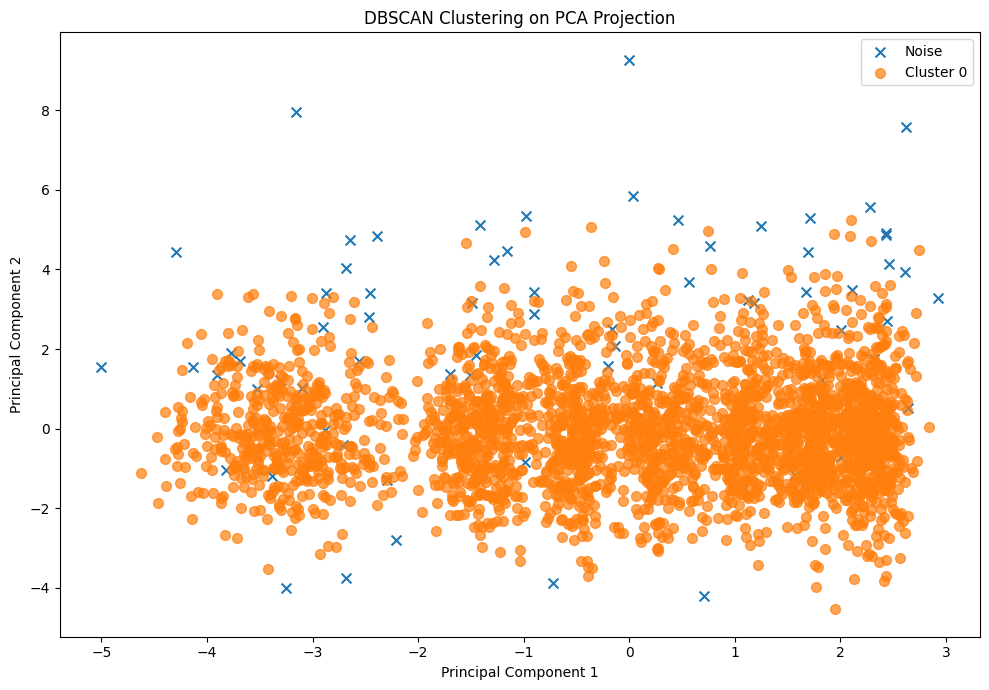

In [16]:
plt.figure(figsize=(10, 7))

unique_labels = sorted(np.unique(dbscan_labels))

for label in unique_labels:
    mask = (dbscan_labels == label)
    
    if label == -1:
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            marker="x",
            s=50,
            label="Noise"
        )
    
    else:
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            s=50,
            alpha=0.7,
            label=f"Cluster {label}"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering on PCA Projection")

plt.legend()
plt.tight_layout()

plt.show()